In [ ]:
import pandas as pd
import csv
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau



In [ ]:
def load_data(v):
    with open(f'mutation_dataset_10-06_v{v}\\simulacoes_com_erro.pkl', 'rb') as arquivo:
        simulacoes_com_erro = pickle.load(arquivo)

    trees_cblv = np.load(f'mutation_dataset_10-06_v{v}\\tree_data.npy')
    trees_cblv = np.delete(trees_cblv, simulacoes_com_erro, axis=0)

    #R_0_1, infectuos time and a taxa relativa 
    # Retornando a segunda coluna (coluna referente ao R_nought)
    # e em segunda transformando a lista em um np.array

    tabela_de_parametros = np.load(f'mutation_dataset_10-06_v{v}\\tabela_parametros.npy')
    tabela_de_parametros = np.delete(tabela_de_parametros, simulacoes_com_erro, axis=0)

    R_nought1 = np.array([sublist[0] for sublist in tabela_de_parametros])
    R_nought2 = np.array([sublist[1] for sublist in tabela_de_parametros])
    infectious_time = np.array([sublist[8] for sublist in tabela_de_parametros])
    proportion_tr11_tr22 = np.array([sublist[10] for sublist in tabela_de_parametros])
    
    rescale_factors = np.load(f'mutation_dataset_10-06_v{v}\\rescale_factor.npy')
    rescale_factors = np.delete(rescale_factors, simulacoes_com_erro)

    infectious_time_div_reascale = np.round(infectious_time / rescale_factors, 3)

    mutation_masks = np.load(f'mutation_dataset_10-06_v{v}\\mutation_masks.npy')
    mutation_masks = np.delete(mutation_masks, simulacoes_com_erro, axis=0)

    vectorized = np.column_stack((R_nought1, infectious_time_div_reascale, proportion_tr11_tr22))

    return trees_cblv, vectorized, mutation_masks, rescale_factors

In [3]:
X, y_param, y_mask, rescale_factors = load_data(0)

In [4]:
test_size = 0.1
(X_train, X_test, y_param_train, y_param_test, y_mask_train, y_mask_test) = train_test_split(
    X, y_param, y_mask, test_size=test_size, shuffle=False)

In [5]:
y_mask_train = y_mask_train.reshape(-1, 501, 2)
y_mask_test = y_mask_test.reshape(-1, 501, 2)

In [6]:
scaler = StandardScaler()

y_param_train_scaled = scaler.fit_transform(y_param_train)
y_param_test_scaled = scaler.transform(y_param_test)

In [ ]:
#Essa arquitetura usará mask-weighted pooling, eu irei passar a mascara PREDIZIDA realizando soma 
# ponderada com as features que o parameter head irá receber

# Não repetir quando eu upar dados novos
inputs = layers.Input(shape=X_train[0].shape)
# Shared backbone
x = layers.Reshape((501, 2))(inputs)
x = layers.Conv1D(filters=50, kernel_size=3, activation='relu', padding='same')(x)
x = layers.Conv1D(filters=50, kernel_size=10, activation='relu', padding='same')(x)


#Mask head
m = layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='same')(x)
mask_output = layers.Conv1D(filters=2, kernel_size=1, activation='sigmoid', padding='same', name='mask')(m)


#parameters head 
p = layers.MaxPooling1D(pool_size=10)(x)
p = layers.Conv1D(filters=80, kernel_size=10, activation='relu', padding='same')(p)


# o stop_gradient é usado para impedir que o gradiente flua de volta 
# através da máscara durante o treinamento, garantindo que a máscara seja tratada 
# como uma entrada fixa ao calcular a atenção. Isso ajuda a estabilizar o treinamento e evita 
# que a máscara aprenda a se ajustar aos parâmetros de saída, mantendo sua função de atenção separada.
mask_p = layers.Lambda(lambda t: keras.ops.stop_gradient(t))(mask_output)
mask_p = layers.MaxPooling1D(pool_size=10)(mask_p)
attention = layers.Conv1D(filters=80, kernel_size=1, activation='sigmoid', padding='same')(mask_p)

p_weighted = layers.Multiply()([p, attention])

# Pool both representations
p = layers.GlobalAveragePooling1D()(p)
p_weighted = layers.GlobalAveragePooling1D()(p_weighted)

#-------------------------------------------------
# Concatenate parameter features with mask features and then normalize
p = layers.Concatenate()([p, p_weighted])
p = layers.LayerNormalization()(p)
#-------------------------------------------------
p = layers.Dense(64, activation='elu')(p) 
p = layers.Dense(32, activation='elu')(p) 
p = layers.Dense(16, activation='elu')(p) 
p = layers.Dense(8, activation='elu')(p)
parameter_output = layers.Dense(3, activation='linear', name='parameters')(p)



modelo = Model(inputs=inputs, outputs=[parameter_output, mask_output])
modelo.compile(optimizer='adam', loss={'parameters': 'mse', 'mask': 'binary_crossentropy'},
               loss_weights={'parameters': 10.0, 'mask': 1.0}, metrics={'parameters': ['mse', 'mae'], 'mask': ['accuracy']})
modelo.summary() 

# Como é a perda é calculada para três parâmetros distintos?
# Treinar uma rede neural passando o cblv e a máscara correta. Tentar tambem separar o proportion

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1002)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 501, 2)    │          0 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 501, 50)   │        350 │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 501, 50)   │     25,050 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 501, 32)   │      4,832 │ conv1d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mask (Conv1D)       │ (None, 501, 2)    │         66 │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 501, 2)    │          0 │ mask[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 50, 50)    │          0 │ conv1d_1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 50, 2)     │          0 │ lambda[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 50, 80)    │     40,080 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 50, 80)    │        240 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 50, 80)    │          0 │ conv1d_3[0][0],   │
│                     │                   │            │ conv1d_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 80)        │          0 │ conv1d_3[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 80)        │          0 │ multiply[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 160)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 160)       │        320 │ concatenate[0][0] │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │     10,304 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │      2,080 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │        528 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 8)         │        136 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ parameters (Dense)  │ (None, 3)         │         27 │ dense_3[0][0]   

 Total params: 84,013 (328.18 KB)

 Trainable params: 84,013 (328.18 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
early_stop = EarlyStopping(monitor='val_parameters_mse', mode='min', patience=20, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_parameters_mse', factor=0.5, patience=5, min_lr=1e-6, verbose=1)

In [9]:
history = modelo.fit(
    X_train, [y_param_train_scaled, y_mask_train],
    validation_data=(X_test,[y_param_test_scaled, y_mask_test]),
    epochs=100, batch_size=32, callbacks=[early_stop, reduce_lr])

Epoch 1/100
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 222s 78ms/step - loss: 9.4905 - mask_accuracy: 0.5892 - mask_loss: 1.5376 - parameters_loss: 7.9529 - parameters_mae: 3.0938 - parameters_mse: 12.3178 - val_loss: 11.6356 - val_mask_accuracy: 0.7275 - val_mask_loss: 1.1680 - val_parameters_loss: 10.4740 - val_parameters_mae: 3.8762 - val_parameters_mse: 16.5768 - learning_rate: 0.0010
Epoch 2/100
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 209s 74ms/step - loss: 11.7993 - mask_accuracy: 0.6806 - mask_loss: 1.1673 - parameters_loss: 10.6320 - parameters_mae: 3.8955 - parameters_mse: 16.7445 - val_loss: 11.6095 - val_mask_accuracy: 0.6573 - val_mask_loss: 1.1416 - val_parameters_loss: 10.4740 - val_parameters_mae: 3.9020 - val_parameters_mse: 16.8145 - learning_rate: 0.0010
Epoch 3/100
2813/2813 ━━━━━━━━━━━━━━━━━━━━ 211s 75ms/step - loss: 11.7771 - mask_accuracy: 0.6378 - mask_loss: 1.1326 - parameters_loss: 10.6445 - parameters_mae: 3.9136 - parameters_mse: 16.9192 - val_loss: 11.5777 - val_mask_accuracy: 0

In [26]:
pred_params_scaled, pred_mask = modelo.predict(X_test)
pred_params = scaler.inverse_transform(pred_params_scaled)
real_params = scaler.inverse_transform(y_param_test_scaled)


313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step


In [27]:
y_param_train.shape, y_param_test.shape, y_mask_train.shape, y_mask_test.shape, rescale_factors.shape

((89994, 3), (10000, 3), (89994, 501, 2), (10000, 501, 2), (99994,))

In [28]:
pred_params[:, 1] *= rescale_factors[-10000:]
real_params[:, 1] *= rescale_factors[-10000:]

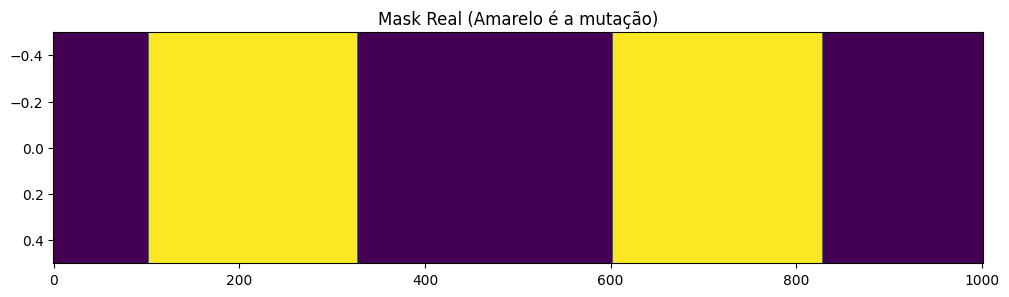

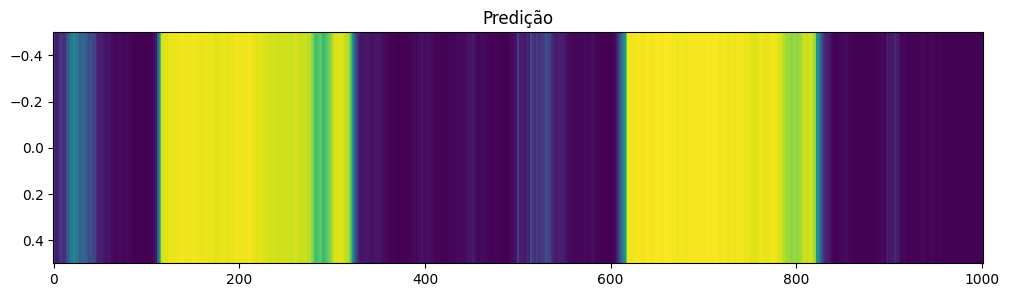

In [29]:
sample = 121

plt.figure(figsize=(12,3))
plt.imshow(y_mask_test[sample].reshape(-1, 1002), aspect='auto')
plt.title("Mask Real (Amarelo é a mutação)")
plt.show()

plt.figure(figsize=(12,3))
plt.imshow(pred_mask[sample].reshape(-1, 1002), aspect='auto')
plt.title("Predição")
plt.show()

In [14]:
mse_por_variavel = np.mean((pred_params - real_params) ** 2, axis=0)
print("MSE R0:", mse_por_variavel[0])
print("MSE infectious_time:", mse_por_variavel[1])
print("MSE proportion:", mse_por_variavel[2])

MSE R0: 48.1472588142506
MSE infectious_time: 76.62964669079639
MSE proportion: 4.949867218156079


In [15]:
erros = np.abs(pred_params - real_params)
mae_por_variavel = np.mean(erros, axis=0)

print("MAE R0:", mae_por_variavel[0])
print("MAE infectious_time:", mae_por_variavel[1])
print("MAE proportion:", mae_por_variavel[2])

MAE R0: 6.802061750744832
MAE infectious_time: 7.120635906604103
MAE proportion: 2.104424188164909


In [16]:
erro_relativo = np.mean(np.abs((pred_params - real_params) / real_params), axis=0)

print("Erro relativo R0:", erro_relativo[0])
print("Erro relativo time:", erro_relativo[1])
print("Erro relativo proportion:", erro_relativo[2])

Erro relativo R0: 2.816222108342307
Erro relativo time: 1.3181308510757213
Erro relativo proportion: 0.9353277696498687


In [17]:
print(np.corrcoef(real_params[:,0], pred_params[:,0])[0,1])
print(np.corrcoef(real_params[:,1], pred_params[:,1])[0,1])
print(np.corrcoef(real_params[:,2], pred_params[:,2])[0,1])

0.6797942958333779
-0.14419324677765094
0.09449351474792664


In [21]:
path = "C:\\Users\\JPC\\Documents\\MESTRADO\\Projeto\\gillespie-2\\neural_networks_dot_keras\\01-07\\mask_guided_fusion_idea"

modelo.save(path + "\\modelo_mask_01-07.keras")

with open(path + "\\scaler_mask_01-07.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open(path + "\\history_mask_01-07.pkl", "wb") as f:
    pickle.dump(history.history, f)

In [30]:
print(modelo.output_names)

ListWrapper(['parameters', 'mask'])


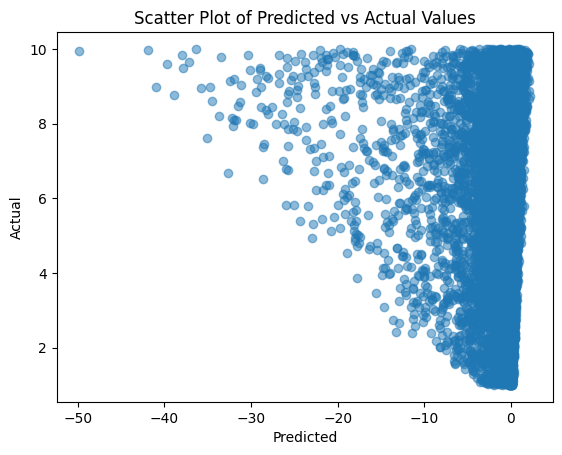

In [19]:
plt.scatter(pred_params[:, 1], real_params[:, 1], alpha=0.5)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Scatter Plot of Predicted vs Actual Values')
plt.show()